In [ ]:
with open('names.txt') as fobj:
    names = fobj.read().split('\n') # split file context at newline

In [2]:
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
# map letters to integer indices, including '.' (end-of-word character)
# this will help us build a transition matrix
alphabet = ".abcdefghijklmnopqrstuvwxyz"
idx = {letter:index for index, letter in enumerate(alphabet)}
idx

{'.': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [4]:
all_names = '.'+'.'.join(names)
all_names

'.emma.olivia.ava.isabella.sophia.charlotte.mia.amelia.harper.evelyn.abigail.emily.elizabeth.mila.ella.avery.sofia.camila.aria.scarlett.victoria.madison.luna.grace.chloe.penelope.layla.riley.zoey.nora.lily.eleanor.hannah.lillian.addison.aubrey.ellie.stella.natalie.zoe.leah.hazel.violet.aurora.savannah.audrey.brooklyn.bella.claire.skylar.lucy.paisley.everly.anna.caroline.nova.genesis.emilia.kennedy.samantha.maya.willow.kinsley.naomi.aaliyah.elena.sarah.ariana.allison.gabriella.alice.madelyn.cora.ruby.eva.serenity.autumn.adeline.hailey.gianna.valentina.isla.eliana.quinn.nevaeh.ivy.sadie.piper.lydia.alexa.josephine.emery.julia.delilah.arianna.vivian.kaylee.sophie.brielle.madeline.peyton.rylee.clara.hadley.melanie.mackenzie.reagan.adalynn.liliana.aubree.jade.katherine.isabelle.natalia.raelynn.maria.athena.ximena.arya.leilani.taylor.faith.rose.kylie.alexandra.mary.margaret.lyla.ashley.amaya.eliza.brianna.bailey.andrea.khloe.jasmine.melody.iris.isabel.norah.annabelle.valeria.emerson.adalyn.r

In [5]:
# tally up all letter transitions

import numpy as np
transition_counts = np.zeros((27, 27))
for char1, char2 in zip(all_names[:-1], all_names[1:]):
    print(char1, char2)
    # what should the order of indices be?
    transition_counts[idx[char2], idx[char1]] += 1

. e
e m
m m
m a
a .
. o
o l
l i
i v
v i
i a
a .
. a
a v
v a
a .
. i
i s
s a
a b
b e
e l
l l
l a
a .
. s
s o
o p
p h
h i
i a
a .
. c
c h
h a
a r
r l
l o
o t
t t
t e
e .
. m
m i
i a
a .
. a
a m
m e
e l
l i
i a
a .
. h
h a
a r
r p
p e
e r
r .
. e
e v
v e
e l
l y
y n
n .
. a
a b
b i
i g
g a
a i
i l
l .
. e
e m
m i
i l
l y
y .
. e
e l
l i
i z
z a
a b
b e
e t
t h
h .
. m
m i
i l
l a
a .
. e
e l
l l
l a
a .
. a
a v
v e
e r
r y
y .
. s
s o
o f
f i
i a
a .
. c
c a
a m
m i
i l
l a
a .
. a
a r
r i
i a
a .
. s
s c
c a
a r
r l
l e
e t
t t
t .
. v
v i
i c
c t
t o
o r
r i
i a
a .
. m
m a
a d
d i
i s
s o
o n
n .
. l
l u
u n
n a
a .
. g
g r
r a
a c
c e
e .
. c
c h
h l
l o
o e
e .
. p
p e
e n
n e
e l
l o
o p
p e
e .
. l
l a
a y
y l
l a
a .
. r
r i
i l
l e
e y
y .
. z
z o
o e
e y
y .
. n
n o
o r
r a
a .
. l
l i
i l
l y
y .
. e
e l
l e
e a
a n
n o
o r
r .
. h
h a
a n
n n
n a
a h
h .
. l
l i
i l
l l
l i
i a
a n
n .
. a
a d
d d
d i
i s
s o
o n
n .
. a
a u
u b
b r
r e
e y
y .
. e
e l
l l
l i
i e
e .
. s
s t


Text(0, 0.5, 'next letter')

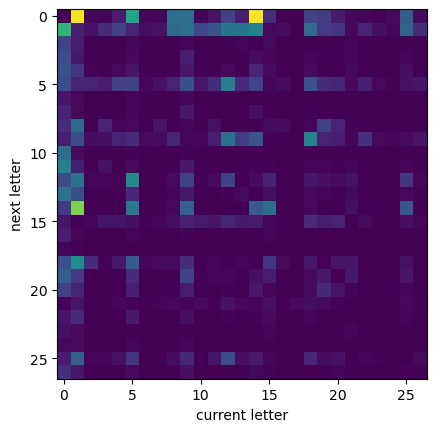

In [6]:
# visualize the counts matrix
import matplotlib.pyplot as plt

plt.imshow(transition_counts)
plt.xlabel('current letter')
plt.ylabel('next letter')

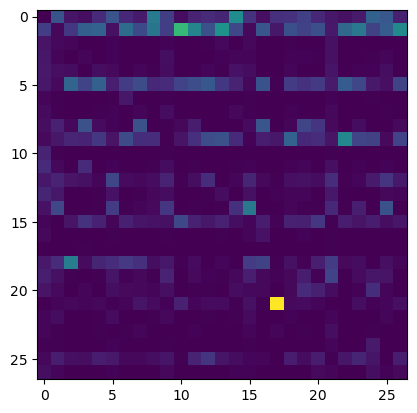

In [7]:
# normalize to get probabilities: each column should sum to 1
transition_probabilities = transition_counts.copy()
for i in range(27):
    transition_probabilities[:, i] /= transition_probabilities[:, i].sum()
plt.imshow(transition_probabilities)

In [8]:
np.sum(transition_probabilities, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [12]:
# now generate some names
# start with the end-of-word character '.'

def generate_name(starting_char='.'):
    rng = np.random.default_rng()

    word = starting_char
    done = False
    while not done:
        lastchar = word[-1]
        i = idx[lastchar]
        j = rng.choice(27, p=transition_probabilities[:, i])
        nextchar = alphabet[j]
        word = word + nextchar
        if nextchar=='.':
            done=True

    return word

In [13]:
for _ in range(10):
    print(generate_name())

.tena.
.lllinlysurirakadeteelylian.
.kh.
.dridara.
.s.
.ahelifaleneegiaymajae.
.mostviayllus.
.olig.
.zy.
.tr.
